#  Dataset Exploration

Explore the characteristics of meeting transcripts and their summaries.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

with open('../data/public/meeting_examples.json') as f:
    data = json.load(f)


df = pd.DataFrame(data)
df.head()

,text,summary
0,The product strategy meeting included a heated...,Sarah and Tom debated retention vs acquisition...
1,"In the customer feedback review, Emily highlig...",Emily flagged delivery delays; Ana's AI propos...
2,"During the HR sync, James mentioned morale iss...",James raised morale issues; Clara's survey pro...
3,The budget alignment meeting revealed overspen...,Pierre and Lisa negotiated R&D budget; milesto...


###  text length features

In [2]:
df['text_len'] = df['text'].apply(lambda x: len(x.split()))
df['summary_len'] = df['summary'].apply(lambda x: len(x.split()))
df[['text_len', 'summary_len']].describe()

,text_len,summary_len
count,4.000000,4.000000
mean,34.500000,11.500000
std,6.244998,1.914854
min,27.000000,10.000000
25%,31.500000,10.000000
50%,34.500000,11.000000
75%,37.500000,12.500000
max,42.000000,14.000000


###  Distribution of text and summary lengths

c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

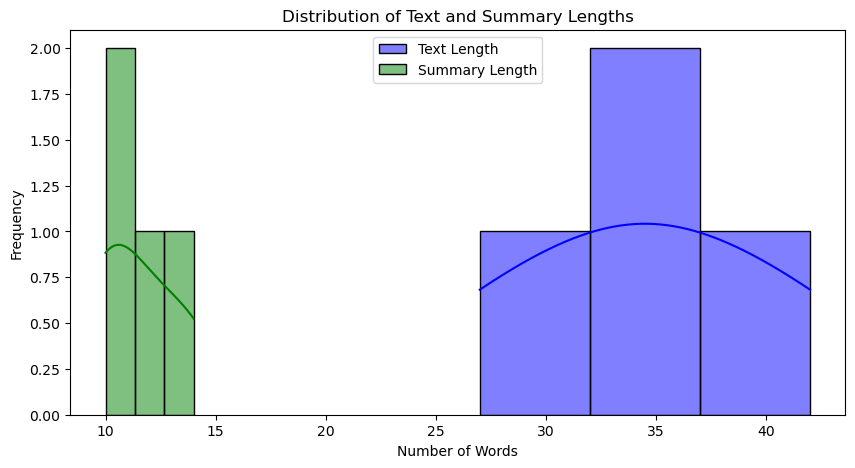

In [3]:
plt.figure(figsize=(10,5))
sns.histplot(df['text_len'], kde=True, color='blue', label='Text Length')
sns.histplot(df['summary_len'], kde=True, color='green', label='Summary Length')
plt.legend()
plt.title('Distribution of Text and Summary Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

###  Compression Ratio

In [4]:
df['compression_ratio'] = df['summary_len'] / df['text_len']
df[['text_len', 'summary_len', 'compression_ratio']]

,text_len,summary_len,compression_ratio
0,42,14,0.333333
1,36,12,0.333333
2,33,10,0.303030
3,27,10,0.370370
